## Sampler

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google/distributed_graph_flow/blob/main/doc/docs/tutorial/sampler.ipynb)

This tutorial shows the different options to generate graph samples.

You'll learn how to use the in-memory sampler and the semi-distributed Beam sampler.

## Importing libraries

In [ ]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import dgf  # Import Graph Flow
import numpy as np

## Load some data

Let's start by loading a toy dataset.

In [ ]:
# Download the Arxiv graph from the OGB repo.
graph, schema = dgf.io.fetch_ogb_graph("arxiv")

Caching arxiv graph at /tmp/gf_fetch/arxiv.cache
OGB dependency not available. Downloading graph from CNS.


In [ ]:
dgf.print.schema(schema)

Graph Schema:

Node Sets:
  nodes:
    | Feature   | Format     | Semantic    | Shape   | Num cat. vals   |
    |-----------|------------|-------------|---------|-----------------|
    | #id       | BYTES      | PRIMARY_ID  | None    | None            |
    | #split    | BYTES      | CATEGORICAL | None    | None            |
    | feat      | FLOAT_32   | EMBEDDING   | (128,)  | None            |
    | labels    | INTEGER_64 | CATEGORICAL | None    | 40              |
    | year      | INTEGER_64 | NUMERICAL   | None    | None            |


Edge Sets:
  edges: (Source: nodes, Target: nodes)
    (No features)



## In-process Sampler

GF has an in-memory graph sampler that implements GraphSAGE and other graph
sampling algorithms.

Let's initialize a sampler.

In [ ]:
# Create a sampler
sampler_config = dgf.sampling.SimpleSamplingConfig(
    # Start the expansion at the "nodes" nodeset.
    # Note: This graph only has one nodeset.
    seed_nodeset="nodes",
    # Maximum distances to consider.
    num_hops=2,
    # How many neighbors we consider at each hop.
    hop_width=2,
    # Follow the edges on both directions.
    reverse=True,
)

sampler = dgf.sampling.create_sampler(
    graph=graph,
    schema=schema,
    plan=sampler_config,
    num_threads=5,
)

We can now generate and plot a graph sample.

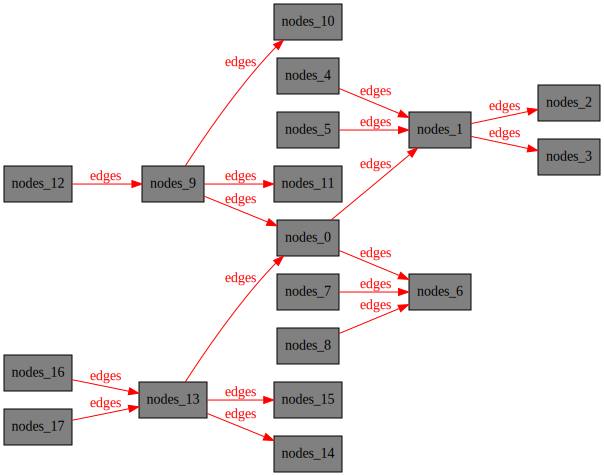

In [ ]:
sample = sampler.sample(seed_node_idxs=0)
dgf.plot.plot_graph(sample, schema, features=False)

**Remarks:**

-   `features=False` removes the features from the plot. It is great for
    visualizing the topology of the graph.
-   In a sample, the first node (`nodes_0`) is always the one the sample was
    generated for (specified with `seed_node_idxs=0`, a.k.a. the seed node).
-   Sampling one seed node at a time is not very efficient; in practice, it is
    better to provide multiple seed nodes, e.g., `seed_node_idxs=[0,1,2]`.
-   Since `seed_node_idxs` is an integer, `sample` returns a single sample. If
    `seed_node_idxs` were a list, `sample` would return a list of samples.

While `SimpleSamplingConfig` offers basic options, you can use a `SamplingPlan`
for more granular control (e.g., managing individual hops).

To see what a SamplingPlan looks like, use the
`simple_sampling_config_to_sampling_plan` method to convert your simple
configuration into a full plan.

In [ ]:
sampling_plan = dgf.sampling.simple_sampling_config_to_sampling_plan(
    sampler_config, schema=schema
)
sampling_plan

SamplingPlan(root=PlanNode(nodeset='nodes', children=[PlanEdge(edgeset='edges', reversed=False, node=PlanNode(nodeset='nodes', children=[PlanEdge(edgeset='edges', reversed=False, node=PlanNode(nodeset='nodes', children=[]), hop_width=2), PlanEdge(edgeset='edges', reversed=True, node=PlanNode(nodeset='nodes', children=[]), hop_width=2)]), hop_width=2), PlanEdge(edgeset='edges', reversed=True, node=PlanNode(nodeset='nodes', children=[PlanEdge(edgeset='edges', reversed=False, node=PlanNode(nodeset='nodes', children=[]), hop_width=2), PlanEdge(edgeset='edges', reversed=True, node=PlanNode(nodeset='nodes', children=[]), hop_width=2)]), hop_width=2)]), with_replacement=False, edgeset_timestamp_features={})

In [ ]:
dgf.print.sampling_plan(sampling_plan)

Sampling Plan:

Root: nodes
├── edges [width=2] ➔ nodes
│   ├── edges [width=2] ➔ nodes
│   └── edges (reversed) [width=2] ➔ nodes
└── edges (reversed) [width=2] ➔ nodes
    ├── edges [width=2] ➔ nodes
    └── edges (reversed) [width=2] ➔ nodes


To be more efficient, let's sample multiple graphs at the same time:

In [ ]:
samples = sampler.sample(seed_node_idxs=[0, 1])
print(
    "Number of nodes in the first graph:",
    samples[0].node_sets["nodes"].num_nodes,
)
print(
    "Number of nodes in the second graph:",
    samples[1].node_sets["nodes"].num_nodes,
)

Number of nodes in the first graph: 18
Number of nodes in the second graph: 6


Many GF functions use iterators / generators. Let's wrap our sampler into a
generator and show some of those functions:

In [ ]:
# Create a generator of graph samples.
def sample_generator(num_batches: int = 10, batch_size: int = 4):
  num_nodes = graph.node_sets["nodes"].num_nodes
  for _ in range(num_batches):
    seed_node_idxs = np.random.choice(num_nodes, size=batch_size, replace=False)
    samples = sampler.sample(seed_node_idxs)
    for sample in samples:
      yield sample


# Test the generator.
for sample in sample_generator():
  print(".", end="")
print("Done generating")

........................................Done generating


For example, the `dgf.io.write_tfgnn_graphs` function takes a graph generator,
and saves the values to a TF-GNN Graph record.

In [ ]:
# Write the graph samples to disk.
dgf.io.write_tfgnn_graphs(
    graphs=sample_generator(),
    schema=schema,
    path="/tmp/samples_graph.tfrecord.gz",
)

When learning GNNs, you will likely batch multiple graphs together. The `merge`
method takes a list of graphs, and returns a single merged graph.

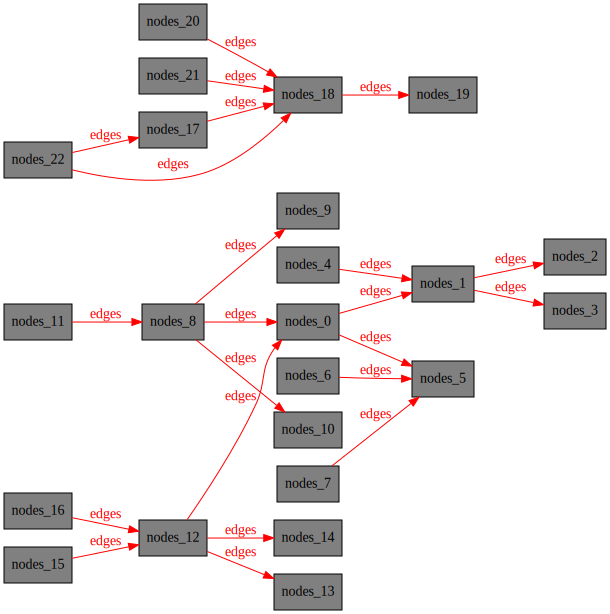

In [ ]:
samples = sampler.sample(seed_node_idxs=[0, 1])
merged_graph, offset = dgf.transform.merge_graphs(
    graphs=samples, schema=schema, padding=None
)
dgf.plot.plot_graph(merged_graph, schema, features=False)

The indices of the original graph nodes in the merged graph are available with `offset`:

In [ ]:
offset

{'nodes': array([ 0, 17, 23])}

**Remarks:**

- The last value of the `offset` is a sentinel reporting the number of nodes. Call `merge_graph` with `sentinel_offset=False` to remove it.


## Subgraph extraction

The `sample` method builds graph samples by randomly traversing edges and aggregating all visited edges and nodes. In this section, we will show the `subgraph` method that extracts all the nodes and edges in a certain radius.

By default, `subgraph` returns a single subgraph containing all the nodes and edges at a distance less than or equal to all the seed nodes.


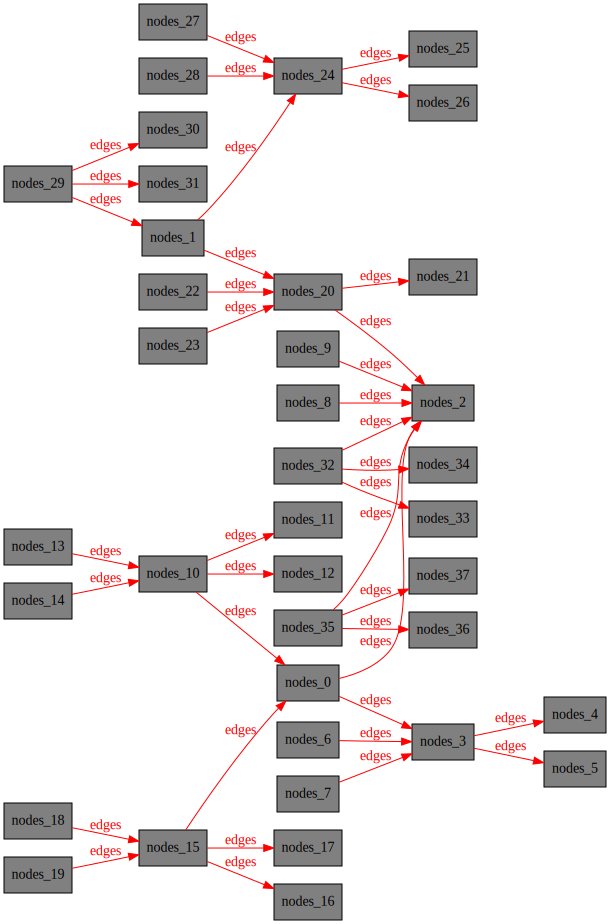

In [ ]:
sample = sampler.subgraph(seed_node_idxs=[0, 150780, 93487])
dgf.plot.plot_graph(sample, schema, features=False)

**Remarks**:

- Notice that all the nodes are connected. This is because the selected seed nodes (0, 150780, 93487)are close.
- By default, `subgraph` runs on a single thread. However, it is fully thread-safe: You can call it in parallel using Python's multi-threading.

`multisubgraph` is related to `subgraph`: Instead of returning a single graph, it returns a separate sub-graph around each seed node:


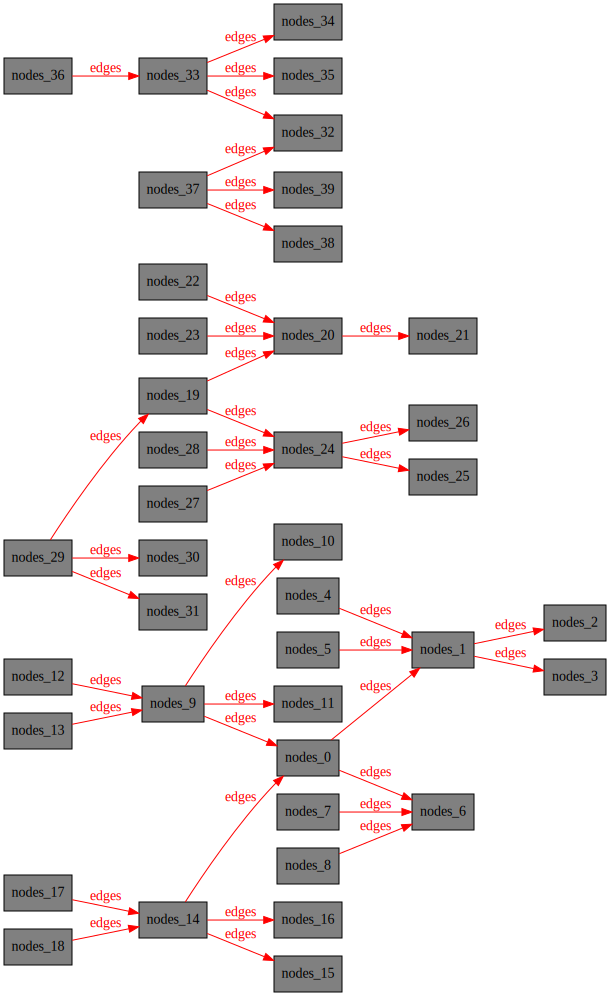

In [ ]:
samples = sampler.multisubgraph(seed_node_idxs=[0, 150780, 93487])

# Grouping the graphs to create a single plot.
merge_graph, offset = dgf.transform.merge_graphs(
    graphs=samples, schema=schema, padding=None
)
dgf.plot.plot_graph(merge_graph, schema, features=False)


**Remark:**

- Notice the 3 independent subgraphs.
- `multisubgraph` is multi-threaded (one thread per subgraphs).

## Temporal masking

Some applications require sampling graphs with temporal masking. This means only
sampling nodes and edges with a timestamp before a specific value, where the
limit changes for each sample.

In GF, temporal sampling filters edge timestamps. If your dataset uses node
timestamps, use the `propagate_timestamp_to_edges` utility function to set each
edge timestamp to the higher value of its two connected nodes.

The following example shows how to create a graph with node timestamps, convert
them to edge timestamps, and perform temporal sampling.

Let's Arxiv graph contains `year` features on the nodes that we can use as a
timestamp, and propagate to the edges.

In [ ]:
# Propagate the node timestamps to the edges
time_graph, time_schema = dgf.transform.propagate_timestamp_to_edges(
    graph, schema, node_timestamps="year"
)
dgf.print.schema(time_schema)

Graph Schema:

Node Sets:
  nodes:
    | Feature   | Format     | Semantic    | Shape   | Num cat. vals   |
    |-----------|------------|-------------|---------|-----------------|
    | #id       | BYTES      | PRIMARY_ID  | None    | None            |
    | #split    | BYTES      | CATEGORICAL | None    | None            |
    | feat      | FLOAT_32   | EMBEDDING   | (128,)  | None            |
    | labels    | INTEGER_64 | CATEGORICAL | None    | 40              |
    | year      | INTEGER_64 | NUMERICAL   | None    | None            |


Edge Sets:
  edges: (Source: nodes, Target: nodes)
    | Feature    | Format     | Semantic   | Shape   | Num cat. vals   |
    |------------|------------|------------|---------|-----------------|
    | timestamps | INTEGER_64 | TIMESTAMP  | None    | None            |



The following example shows how to create a graph with node timestamps, convert
them to edge timestamps, and perform temporal sampling.

In [ ]:
# Create a sampler
time_sampler_config = dgf.sampling.SimpleSamplingConfig(
    seed_nodeset="nodes",
    num_hops=2,
    hop_width=2,
    reverse=True,
    # This is the new part: This is a dict of edgeset names to the timestamp feature.
    edgeset_timestamp_features={"edges": "timestamps"},
)

time_sampler = dgf.sampling.create_sampler(
    graph=time_graph,
    schema=time_schema,
    plan=time_sampler_config,
    num_threads=5,
)

Let's look at the year of the first node:

In [ ]:
time_graph.node_sets["nodes"].features["year"][0]

np.int64(2013)

So, let's create a graph sample by only considering edges prior (non-strict)
to 2013.

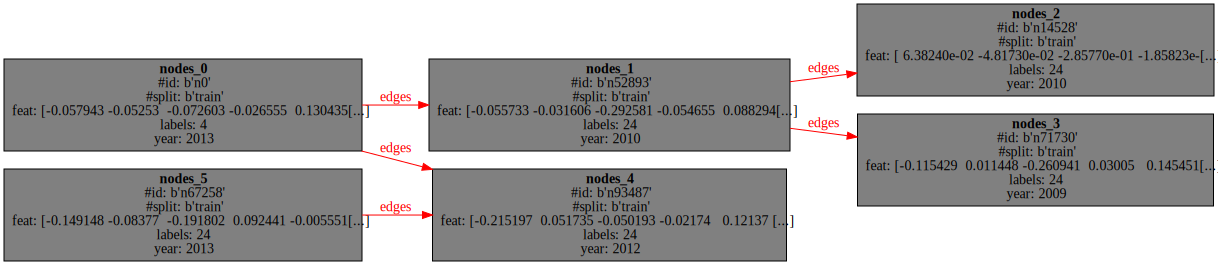

In [ ]:
sample = time_sampler.sample(seed_node_idxs=0, seed_timestamps=2013)
dgf.plot.plot_graph(sample, schema, features=True)

## Semi-distributed sampler (v2)

The semi-distributed sampler is a simple way to distribute the computation of
graph samples over multiple machines using Apache Beam. It is not a fully
distributed sampler though: Each worker will load the full graph topology (i.e.,
the edges; but not the features) in memory.

**Note:** For a full example, check
`dgf/examples/create_graph_samples_semi_distributed_v2.py`.

Let's configure and run the semi-distributed graph sampler:

In [ ]:
from absl import flags
import apache_beam as beam
from apache_beam.options import pipeline_options
from google3.pipeline.flume.py import runner as flume_runner

# For the user: Comment / uncomment on of the block.
# Note: Defining the "flume_exec_mode" in the "PipelineOptions" does not work.

# Run the execution in-process. Great for debugging / iteration on small data.
# ===
flags.FLAGS.flume_exec_mode = "IN_PROCESS"
options = pipeline_options.PipelineOptions()

# Run the execution on Borg. Great for large data.
# ===
# flags.FLAGS.flume_exec_mode = "BORG"
# options = pipeline_options.PipelineOptions(
#     flume_borg_accounting_charged_user_name="simple-ml-accounting",
#     flume_borg_cells="is",
#     flume_use_batch_scheduler=True,
#     flume_batch_scheduler_strategy="RUN_SOON",
# )

Save our graph to disk. This will be the input of the sampler.

In [ ]:
graph_path = "/tmp/my_graph"
dgf.io.write_graph(graph, schema, path=graph_path)

GFGraph written from memory in 0.62 seconds


In [ ]:
with beam.Pipeline(runner=flume_runner.FlumeRunner(), options=options) as root:

  # Read only the node and the #id feature from the graph. Those
  # is the nodes to seed.
  seed_graph = dgf.beam.io.read_graph(
      root,
      graph_path,
      schema_filter=dgf.data.GraphSchemaFilter(
          nodeset_fn=lambda key, sch: key == "nodes",
          edgeset_fn=lambda key, sch: False,
          feature_fn=lambda key, sch: key == "#id",
      ),
  )
  seed_node_ids = dgf.beam.sampling.extract_nodes_ids(seed_graph, "nodes")

  # Alternatively, you can do:
  # seed_node_ids = beam.Create([b"<id of node>", b"<id of node>"])

  # Randomly select 50 seed nodes.
  seed_node_ids = (
      seed_node_ids
      | "Sample seeds" >> beam.combiners.Sample.FixedSizeGlobally(50)
      | beam.FlatMap(lambda xs: xs)
  )

  # Generate samples
  samples, output_schema = dgf.beam.sampling.semi_distributed_sampler_v2(
      graph_path=graph_path,
      plan=sampler_config,
      seeds=seed_node_ids,
      num_threads=20,
      beam_feature_collection=False,
  )

  # Save the samples to disk
  dgf.beam.io.write_tfgnn_graphs(samples, "/tmp/samples@*", output_schema)

Using override schema
Reading 1 nodeset(s), 1 edgeset(s), and 5 feature(s)
Reading metadata from /tmp/my_graph
Reading nodeset nodes from /tmp/my_graph
.concatenating values
Reading edgeset edges from /tmp/my_graph
.concatenating values
GFGraph read in memory in 0.47 seconds


**Remark:**

-   The semi-distributed sampler (v2) takes as input a graph stored on disk. It
    is today, the fastest option (faster than loading the input graph from a
    beam pcollection like the v1).
-   The `num_threads` option control the number of threads for each worker.
-   Setting `beam_feature_collection=True` tells the sampler to generate
    topologies first and then collect feature values using Apache Beam. This
    approach scales effectively because workers only store the graph topology in
    memory, though it results in slower overall performance. Alternatively,
    `beam_feature_collection=False` triggers feature collection at the same time
    the sampler generates the topology. While this method is faster, it requires
    workers to load all feature values into memory, which limits its ability to
    scale.
-   Note that all the beam method start with `dgf.beam.*`.

We can now load and plot the graph samples.

In [ ]:
graphs = list(dgf.io.read_tfgnn_graphs(path="/tmp/samples@*", schema=schema))
print(f"Found {len(graphs)} graphs")

found 50 graphs
